<!-- CELL 1 — MARKDOWN -->
# Phase 3 — Naive Baseline Model
### Uplift Modeling on the Hillstrom Email Marketing Dataset

**Project:** `uplift-causal-ml` — a 7-phase causal machine learning project on uplift modeling.

**Recap:** Phase 1 loaded and validated the Hillstrom dataset; Phase 2 encoded the
features and produced a stratified 80/20 train/test split, saved to `data/processed/`.

**This notebook (Phase 3) covers:**
1. Loading the exact Phase 2 split from `data/processed/` (no re-splitting)
2. Setting `visit` as the primary target (`conversion` as a secondary sanity check --
   see the note in Section 2 on why this changed from the original plan)
3. Training a plain LightGBM classifier to predict the primary target --
   **without** using treatment as a feature
4. Handling class imbalance
5. Evaluating with AUC-ROC, precision, recall, and a precision-recall curve
6. A permanent top-decile-vs-rest signal check on the ranking
7. Producing a "naive targeting" ranking of test customers by predicted probability
8. Saving the model and the ranking
9. A closing summary framing this as the standard predictive-ML approach that
   Phase 4's uplift models will be contrasted against


<!-- CELL 2 — MARKDOWN -->
## 1. Load the Phase 2 split from `data/processed/`

In [1]:
# ---------------------------------------------------------------------------
# CELL 3 — CODE: Load X_train/X_test, treatment_train/treatment_test, and
# y_train/y_test DIRECTLY from data/processed/ -- the exact split Phase 2
# produced. We deliberately do NOT reload the raw dataset or call
# train_test_split again here: doing so would silently produce a different
# split, which would make any later comparison between this baseline model
# and the Phase 4 uplift models invalid.
# ---------------------------------------------------------------------------
import os
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score,
)
from IPython.display import Markdown, display

processed_dir = os.path.join("..", "data", "processed")

X_train = pd.read_csv(os.path.join(processed_dir, "X_train.csv"))
X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv"))
treatment_train = pd.read_csv(os.path.join(processed_dir, "treatment_train.csv"))["treatment"]
treatment_test = pd.read_csv(os.path.join(processed_dir, "treatment_test.csv"))["treatment"]
y_train = pd.read_csv(os.path.join(processed_dir, "y_train.csv"))
y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv"))

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"treatment_train: {treatment_train.shape}   treatment_test: {treatment_test.shape}")
print(f"y_train: {y_train.shape}   y_test: {y_test.shape}")
print(f"\nX_train columns ({X_train.shape[1]}): {X_train.columns.tolist()}")

assert "treatment" not in X_train.columns and "treatment" not in X_test.columns, \
    "Treatment column must not be present in the feature matrix."

# LightGBM rejects feature names containing special JSON characters (e.g. the
# one-hot columns from Phase 2 like "history_segment_7) $1,000 +" contain
# '$', ',', '(', ')'). We sanitize column names to alphanumeric + underscore
# ONLY for LightGBM's benefit -- this does not change which features exist or
# what they mean, just how their names are spelled for this library.
def sanitize_columns(columns):
    return [re.sub(r"[^A-Za-z0-9_]+", "_", str(col)) for col in columns]

original_columns = X_train.columns.tolist()
sanitized_columns = sanitize_columns(original_columns)
assert len(set(sanitized_columns)) == len(sanitized_columns), "Sanitized column names collided -- check original names."

X_train.columns = sanitized_columns
X_test.columns = sanitized_columns

print("\nColumn names sanitized for LightGBM compatibility, e.g.:")
for orig, san in list(zip(original_columns, sanitized_columns))[:3]:
    print(f"  '{orig}' -> '{san}'")


X_train: (51200, 18)   X_test: (12800, 18)
treatment_train: (51200,)   treatment_test: (12800,)
y_train: (51200, 3)   y_test: (12800, 3)

X_train columns (18): ['recency', 'history', 'mens', 'womens', 'newbie', 'history_segment_1) $0 - $100', 'history_segment_2) $100 - $200', 'history_segment_3) $200 - $350', 'history_segment_4) $350 - $500', 'history_segment_5) $500 - $750', 'history_segment_6) $750 - $1,000', 'history_segment_7) $1,000 +', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']

Column names sanitized for LightGBM compatibility, e.g.:
  'recency' -> 'recency'
  'history' -> 'history'
  'mens' -> 'mens'


<!-- CELL 4 — MARKDOWN -->
## 2. Target outcome: `visit` (corrected from `conversion` -- see note below)

**Correction, documented openly:** the primary target for this baseline model was
originally set to `conversion`. After training, the model came back essentially
indistinguishable from random (**AUC-ROC = 0.5141**, and the top-decile conversion rate
was barely above the overall base rate). This isn't a bug -- `conversion` is simply too
rare on this dataset (**~0.9% of customers, only 463 positive examples in the training
set**) for a classifier to learn meaningful signal from with these features. Rather than
report a weak, misleading model as if it were informative, the primary target was switched
to **`visit`**, which has a much more learnable base rate (**~14.7% overall, ~10.6% control
/ ~16.7% treatment, over 7,500 positive examples in training**).

**`conversion` remains available and is still reported throughout this notebook**, but now
as the **secondary, harder-to-predict sanity-check outcome** -- the role `visit` played in
the first version of this notebook is reversed here.


In [2]:
# ---------------------------------------------------------------------------
# CELL 5 — CODE: Define the primary target (visit) and pull out the
# secondary sanity-check outcome (conversion) for later use in evaluation.
# ---------------------------------------------------------------------------
target_col = "visit"
secondary_check_col = "conversion"

y_train_target = y_train[target_col]
y_test_target = y_test[target_col]

train_target_rate = y_train_target.mean()
test_target_rate = y_test_target.mean()

print(f"Primary target             : '{target_col}'  (switched from 'conversion' -- see Section 2)")
print(f"Secondary sanity-check col : '{secondary_check_col}' (not used for training)")
print(f"\nTrain {target_col} rate: {train_target_rate*100:.3f}%  ({int(y_train_target.sum()):,} / {len(y_train_target):,} positive)")
print(f"Test {target_col} rate : {test_target_rate*100:.3f}%  ({int(y_test_target.sum()):,} / {len(y_test_target):,} positive)")


Primary target             : 'visit'  (switched from 'conversion' -- see Section 2)
Secondary sanity-check col : 'conversion' (not used for training)

Train visit rate: 14.662%  (7,507 / 51,200 positive)
Test visit rate : 14.742%  (1,887 / 12,800 positive)


<!-- CELL 6 — MARKDOWN -->
## 3. Train a plain LightGBM classifier (naive baseline -- no treatment feature)

**Why we deliberately exclude `treatment` as a feature here:** this model represents the
naive, common real-world approach of "predict who's likely to visit/convert" and then act
on that prediction (e.g. target the highest-probability customers with a marketing email)
-- **without ever considering whether the intervention itself changes their behaviour.**

That's exactly the flaw this whole project exists to demonstrate. A customer who's very
likely to visit *anyway* (with or without the email) looks identical to this model as a
customer who's likely to visit *only because of* the email -- and a naive approach targets
both the same way, wasting spend on the first group. This model is a **deliberate baseline
to contrast against the uplift models in Phase 4**, not a model we are trying to optimize
or improve in this notebook.


In [3]:
# ---------------------------------------------------------------------------
# CELL 7 — CODE: Train a plain LGBMClassifier on X_train to predict the
# primary target, using ONLY the feature columns -- treatment is
# intentionally excluded (see markdown above for why).
# ---------------------------------------------------------------------------
# scale_pos_weight handles the class imbalance by upweighting the loss
# contribution of the rarer positive class, roughly in proportion to how
# outnumbered it is by the negative class. Computed directly from the
# training set's actual class ratio -- for `visit` (~14.7% positive) this
# works out to roughly 5-8x, a far milder correction than the ~110x needed
# for `conversion`, which is part of why visit is the more learnable target.
n_negative = (y_train_target == 0).sum()
n_positive = (y_train_target == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f"Train class counts -> negative: {n_negative:,}, positive: {n_positive:,}")
print(f"scale_pos_weight = {n_negative:,} / {n_positive:,} = {scale_pos_weight:.2f}")

baseline_model = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=200,
    verbosity=-1,
)

baseline_model.fit(X_train, y_train_target)
print("\nModel trained.")


Train class counts -> negative: 43,693, positive: 7,507
scale_pos_weight = 43,693 / 7,507 = 5.82

Model trained.


<!-- CELL 8 — MARKDOWN -->
## 4. Evaluate on the test set

We report **AUC-ROC**, **precision**, and **recall**, plus a **precision-recall curve**
(more informative than the ROC curve on imbalanced classes, since it's more sensitive to
how the model handles the minority/positive class).

**We deliberately do NOT report plain accuracy as a headline metric.** Even with `visit`'s
milder ~15% positive rate, a trivial model that always predicts "no visit" would still score
a misleadingly high accuracy while having zero recall -- the same issue that would apply even
more severely to the `conversion` secondary check (~99% accuracy, 0 recall, for a model that
never flags a single converter). Accuracy is intentionally omitted as a summary metric
throughout this notebook.


In [4]:
# ---------------------------------------------------------------------------
# CELL 9 — CODE: Predict target probabilities on the test set, then report
# AUC-ROC and (at the default 0.5 threshold) precision/recall.
# ---------------------------------------------------------------------------
test_probs = baseline_model.predict_proba(X_test)[:, 1]
test_preds_default_threshold = (test_probs >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test_target, test_probs)
precision = precision_score(y_test_target, test_preds_default_threshold, zero_division=0)
recall = recall_score(y_test_target, test_preds_default_threshold, zero_division=0)
avg_precision = average_precision_score(y_test_target, test_probs)

print(f"Target                : '{target_col}'")
print(f"AUC-ROC              : {auc_roc:.4f}")
print(f"Precision (@0.5)      : {precision:.4f}")
print(f"Recall (@0.5)         : {recall:.4f}")
print(f"Average Precision (PR area) : {avg_precision:.4f}")
print(f"\n(For reference, a naive 'predict no {target_col} for everyone' model would score "
      f"~{(1 - test_target_rate)*100:.1f}% accuracy while having 0 recall -- which is exactly "
      f"why accuracy is not reported as a headline metric here.)")


Target                : 'visit'
AUC-ROC              : 0.6021
Precision (@0.5)      : 0.1870
Recall (@0.5)         : 0.5416
Average Precision (PR area) : 0.1997

(For reference, a naive 'predict no visit for everyone' model would score ~85.3% accuracy while having 0 recall -- which is exactly why accuracy is not reported as a headline metric here.)


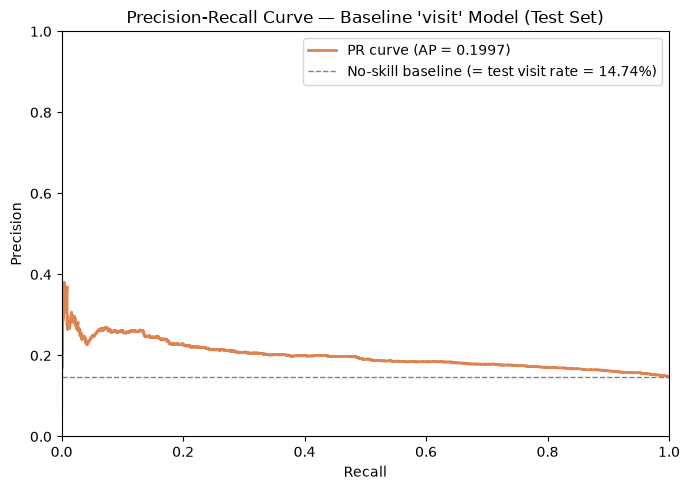

In [5]:
# ---------------------------------------------------------------------------
# CELL 10 — CODE: Plot the precision-recall curve for the test set.
# ---------------------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test_target, test_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, color="#DD8452", linewidth=2, label=f"PR curve (AP = {avg_precision:.4f})")
ax.axhline(y=test_target_rate, color="gray", linestyle="--", linewidth=1,
           label=f"No-skill baseline (= test {target_col} rate = {test_target_rate*100:.2f}%)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve — Baseline '{target_col}' Model (Test Set)")
ax.legend()
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
fig.tight_layout()
plt.show()


<!-- CELL 11 — MARKDOWN -->
### 4a. Secondary sanity check: `conversion`

`conversion` was never used for training -- here we check (in the flipped direction from
the original notebook) whether the model's **visit**-probability ranking is at least
directionally associated with **conversion** too, as a loose sanity check. Given how rare
and noisy conversion is (Section 2), we don't expect a strong relationship, but a value
meaningfully above 0.5 would still be a reasonable sign.


In [6]:
# ---------------------------------------------------------------------------
# CELL 12 — CODE: Secondary sanity check only -- correlate predicted visit
# probability against the (unused-in-training) conversion outcome. This is
# NOT a model evaluation metric, just a directional sanity check.
# ---------------------------------------------------------------------------
secondary_test = y_test[secondary_check_col]
secondary_auc = roc_auc_score(secondary_test, test_probs)

print(f"AUC-ROC of the '{target_col}'-probability ranking against '{secondary_check_col}' (sanity check): {secondary_auc:.4f}")
print("(A value meaningfully above 0.5 suggests the model's ranking is directionally "
      f"sensible for '{secondary_check_col}' too, even though it was never trained on it. "
      "Given how rare/noisy conversion is, a modest value here is expected and fine.)")


AUC-ROC of the 'visit'-probability ranking against 'conversion' (sanity check): 0.5544
(A value meaningfully above 0.5 suggests the model's ranking is directionally sensible for 'conversion' too, even though it was never trained on it. Given how rare/noisy conversion is, a modest value here is expected and fine.)


<!-- CELL 13 — MARKDOWN -->
## 5. Generate the naive targeting ranking

In [7]:
# ---------------------------------------------------------------------------
# CELL 14 — CODE: Build the "naive targeting" ranking -- every test customer,
# their predicted probability for the primary target, and their actual
# treatment/outcomes, sorted descending by predicted probability. This is
# what a business following standard predictive ML would use to decide who
# to target. Both outcome columns (visit and conversion) are included, not
# just the primary target, so the ranking is a complete diagnostic record.
# ---------------------------------------------------------------------------
baseline_ranking = pd.DataFrame({
    "row_index": X_test.index,
    "predicted_prob": test_probs,
    "actual_treatment": treatment_test.values,
    "actual_visit": y_test["visit"].values,
    "actual_conversion": y_test["conversion"].values,
}).sort_values("predicted_prob", ascending=False).reset_index(drop=True)

print(f"Ranking built: {len(baseline_ranking):,} rows (ranked by predicted '{target_col}' probability)")
print("\nTop 10 customers by predicted probability:")
display(baseline_ranking.head(10))

print("\nBottom 5 customers by predicted probability:")
display(baseline_ranking.tail(5))


Ranking built: 12,800 rows (ranked by predicted 'visit' probability)

Top 10 customers by predicted probability:


,row_index,predicted_prob,actual_treatment,actual_visit,actual_conversion
0,4786,0.850989,1,0,0
1,5040,0.850455,1,0,0
2,11866,0.846469,1,1,0
3,12122,0.844203,1,0,0
4,7700,0.842234,1,0,0
5,9718,0.830524,1,0,0
6,5641,0.829979,1,1,0
7,1082,0.827377,1,0,0
8,11614,0.825131,0,0,0
9,12378,0.824253,1,1,0



Bottom 5 customers by predicted probability:


,row_index,predicted_prob,actual_treatment,actual_visit,actual_conversion
12795,7473,0.066309,0,0,0
12796,4794,0.063035,1,0,0
12797,8486,0.062937,1,0,0
12798,6078,0.061473,0,0,0
12799,5704,0.046124,0,0,0


<!-- CELL 15 — MARKDOWN -->
## 6. Signal verification: top 10% vs. bottom 90%

**This check is now a permanent safeguard in this notebook** -- it's exactly the kind of
check that caught the problem with the original `conversion`-based model (whose top-decile
conversion rate was barely above the overall base rate, revealing that the model had
learned essentially nothing useful despite a plausible-looking AUC). We compute the actual
outcome rate within the top 10% of predicted probabilities vs. the bottom 90%, and flag
clearly if the gap isn't meaningfully larger than the base rate.


In [8]:
# ---------------------------------------------------------------------------
# CELL 16 — CODE: Compute the actual primary-target rate in the top 10% of
# predicted probabilities vs. the bottom 90%, and flag if the gap is not
# meaningfully larger than the overall base rate. This is a permanent
# sanity check -- run it every time this notebook is used with a new target.
# ---------------------------------------------------------------------------
# Minimum gap (in absolute rate terms) between top-decile and bottom-90% rate
# to consider the ranking as carrying meaningful signal, rather than noise.
MIN_MEANINGFUL_GAP_PP = 0.02  # 2 percentage points

n_customers = len(baseline_ranking)
top_decile_n = int(np.ceil(n_customers * 0.10))

top_decile = baseline_ranking.iloc[:top_decile_n]
bottom_90pct = baseline_ranking.iloc[top_decile_n:]

outcome_col = f"actual_{target_col}"
overall_rate = baseline_ranking[outcome_col].mean()
top_decile_rate = top_decile[outcome_col].mean()
bottom_90pct_rate = bottom_90pct[outcome_col].mean()
gap_pp = top_decile_rate - bottom_90pct_rate
lift_ratio = (top_decile_rate / overall_rate) if overall_rate > 0 else np.nan

print(f"Verification target        : '{target_col}'")
print(f"Overall base rate          : {overall_rate*100:.3f}%")
print(f"Top 10% predicted rate     : {top_decile_rate*100:.3f}%  (n={top_decile_n:,})")
print(f"Bottom 90% predicted rate  : {bottom_90pct_rate*100:.3f}%  (n={n_customers - top_decile_n:,})")
print(f"Gap (top10 - bottom90)     : {gap_pp*100:+.3f} percentage points")
print(f"Lift over base rate (top10 vs overall) : {lift_ratio:.2f}x")

signal_check_passed = gap_pp >= MIN_MEANINGFUL_GAP_PP
print()
if signal_check_passed:
    print(f"SIGNAL CHECK PASSED: the top-decile rate is {gap_pp*100:.2f} pp above the bottom-90% "
          f"rate (>= the {MIN_MEANINGFUL_GAP_PP*100:.0f} pp threshold) -- the ranking carries "
          "meaningful, learnable signal.")
else:
    print(f"SIGNAL CHECK FAILED: the top-decile rate is only {gap_pp*100:.2f} pp above the bottom-90% "
          f"rate (below the {MIN_MEANINGFUL_GAP_PP*100:.0f} pp threshold) -- this ranking does NOT "
          "carry meaningful signal and should not be trusted for targeting. (This is exactly the "
          "failure mode that was caught when 'conversion' was the primary target.)")


Verification target        : 'visit'
Overall base rate          : 14.742%
Top 10% predicted rate     : 24.062%  (n=1,280)
Bottom 90% predicted rate  : 13.707%  (n=11,520)
Gap (top10 - bottom90)     : +10.356 percentage points
Lift over base rate (top10 vs overall) : 1.63x

SIGNAL CHECK PASSED: the top-decile rate is 10.36 pp above the bottom-90% rate (>= the 2 pp threshold) -- the ranking carries meaningful, learnable signal.


<!-- CELL 17 — MARKDOWN -->
## 7. Save the model and the ranking

In [9]:
# ---------------------------------------------------------------------------
# CELL 18 — CODE: Save the trained model (joblib) and the ranking (CSV) to
# data/processed/, overwriting the earlier conversion-based versions. Phase 4
# will load this exact (visit-based) baseline for comparison.
# ---------------------------------------------------------------------------
model_path = os.path.join(processed_dir, "baseline_model.pkl")
ranking_path = os.path.join(processed_dir, "baseline_ranking.csv")

joblib.dump(baseline_model, model_path)
baseline_ranking.to_csv(ranking_path, index=False)

print(f"Saved model  -> {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")
print(f"Saved ranking -> {ranking_path}  ({os.path.getsize(ranking_path)/1024:.1f} KB)")
print(f"(Both files overwrite the earlier conversion-based versions from the first run.)")


Saved model  -> ..\data\processed\baseline_model.pkl  (675.5 KB)
Saved ranking -> ..\data\processed\baseline_ranking.csv  (391.5 KB)
(Both files overwrite the earlier conversion-based versions from the first run.)


<!-- CELL 19 — MARKDOWN -->
## 8. Phase 3 summary

In [10]:
# ---------------------------------------------------------------------------
# CELL 20 — CODE: Pull together the key evaluation numbers, including the
# documented target-switch decision and the new signal-verification result,
# into one closing summary -- the deliverable for Phase 3.
# ---------------------------------------------------------------------------
summary_md = f"""
### Phase 3 Summary — Naive Baseline Model

**Documented correction:** `conversion` was the original primary target, but it produced a
near-random model (AUC-ROC = 0.5141, top-decile conversion rate barely above the base
rate) -- with only 463 positive examples (~0.9%) in training, there wasn't enough signal
for a classifier to learn from. The primary target was switched to **`visit`**
(~{train_target_rate*100:.1f}% positive, {int(y_train_target.sum()):,} positive examples in
training) as a deliberate, reasoned decision, not a hidden change. `conversion` remains
reported as a secondary sanity-check outcome throughout.

- **Model:** LightGBM binary classifier (`LGBMClassifier`), trained on the 18 Phase 2
  features to predict `{target_col}`, with `scale_pos_weight={scale_pos_weight:.2f}` to
  correct for the ~{train_target_rate*100:.1f}% positive class rate. The `treatment` column
  was intentionally **excluded** from the features.
- **Test set performance:** AUC-ROC = **{auc_roc:.4f}**, Precision = **{precision:.4f}**,
  Recall = **{recall:.4f}** (at the default 0.5 threshold), Average Precision = **{avg_precision:.4f}**.
  (Accuracy is intentionally not reported -- see Section 4.)
- **Signal verification (top 10% vs. bottom 90%):** top-decile {target_col} rate =
  {top_decile_rate*100:.2f}% vs. bottom-90% rate = {bottom_90pct_rate*100:.2f}%
  (gap = {gap_pp*100:+.2f} pp, {lift_ratio:.2f}x lift over the overall base rate) --
  **{'PASSED' if signal_check_passed else 'FAILED'}**. This check is now a permanent part of
  this notebook and should be re-run whenever the target changes.
- **Secondary sanity check:** the `{target_col}`-probability ranking scored
  {secondary_auc:.4f} AUC-ROC against the (unused-in-training) `{secondary_check_col}` outcome.
- **Outputs saved:** `data/processed/baseline_model.pkl` (the trained model) and
  `data/processed/baseline_ranking.csv` ({len(baseline_ranking):,} test customers, ranked
  by predicted `{target_col}` probability, with actual treatment, visit, and conversion all
  attached) -- both overwrite the earlier conversion-based versions.

**Framing:** this is what a business following standard predictive ML would do -- build a
model that predicts who is likely to visit/convert, then target the highest-scoring
customers with a marketing campaign. It never asks *whether the campaign itself would
change that customer's behaviour* -- it would happily spend a marketing budget on
customers who were always going to visit/convert anyway, and might just as easily skip
customers who wouldn't act on their own but *would* respond to the email. **Phase 4 will
build genuine uplift models and show why targeting based on this baseline's ranking is
suboptimal compared to targeting based on estimated treatment effect.**
"""

display(Markdown(summary_md))



### Phase 3 Summary — Naive Baseline Model

**Documented correction:** `conversion` was the original primary target, but it produced a
near-random model (AUC-ROC = 0.5141, top-decile conversion rate barely above the base
rate) -- with only 463 positive examples (~0.9%) in training, there wasn't enough signal
for a classifier to learn from. The primary target was switched to **`visit`**
(~14.7% positive, 7,507 positive examples in
training) as a deliberate, reasoned decision, not a hidden change. `conversion` remains
reported as a secondary sanity-check outcome throughout.

- **Model:** LightGBM binary classifier (`LGBMClassifier`), trained on the 18 Phase 2
  features to predict `visit`, with `scale_pos_weight=5.82` to
  correct for the ~14.7% positive class rate. The `treatment` column
  was intentionally **excluded** from the features.
- **Test set performance:** AUC-ROC = **0.6021**, Precision = **0.1870**,
  Recall = **0.5416** (at the default 0.5 threshold), Average Precision = **0.1997**.
  (Accuracy is intentionally not reported -- see Section 4.)
- **Signal verification (top 10% vs. bottom 90%):** top-decile visit rate =
  24.06% vs. bottom-90% rate = 13.71%
  (gap = +10.36 pp, 1.63x lift over the overall base rate) --
  **PASSED**. This check is now a permanent part of
  this notebook and should be re-run whenever the target changes.
- **Secondary sanity check:** the `visit`-probability ranking scored
  0.5544 AUC-ROC against the (unused-in-training) `conversion` outcome.
- **Outputs saved:** `data/processed/baseline_model.pkl` (the trained model) and
  `data/processed/baseline_ranking.csv` (12,800 test customers, ranked
  by predicted `visit` probability, with actual treatment, visit, and conversion all
  attached) -- both overwrite the earlier conversion-based versions.

**Framing:** this is what a business following standard predictive ML would do -- build a
model that predicts who is likely to visit/convert, then target the highest-scoring
customers with a marketing campaign. It never asks *whether the campaign itself would
change that customer's behaviour* -- it would happily spend a marketing budget on
customers who were always going to visit/convert anyway, and might just as easily skip
customers who wouldn't act on their own but *would* respond to the email. **Phase 4 will
build genuine uplift models and show why targeting based on this baseline's ranking is
suboptimal compared to targeting based on estimated treatment effect.**
